# 03 - Transfer Learning con ResNet-18 Preentrenada


Este notebook desarrolla la Tarea 3. Se utiliza ResNet-18 preentrenada en ImageNet y se comparan Feature Extraction, Fine-tuning parcial y Fine-tuning total contra el mejor modelo entrenado desde cero.


#Verificación de GPU

In [1]:
import torch

print("Versión de PyTorch:", torch.__version__)
print("GPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Versión de PyTorch: 2.10.0+cu128
GPU disponible: True
GPU: Tesla T4


# Integración y verificación de archivo .JSON de Kaggle

In [2]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"axelypr","key":"b1aac0b0298913cfaa35f97c4f65fbb4"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle --version

Kaggle CLI 2.0.2


# Descarga del dataset

In [5]:
!mkdir -p data/blood_cells
!kaggle datasets download -d paultimothymooney/blood-cells -p data/blood_cells
!unzip -q data/blood_cells/blood-cells.zip -d data/blood_cells

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/blood-cells
License(s): other
100% 108M/108M [00:00<00:00, 144MB/s]



In [6]:
!find data/blood_cells -maxdepth 5 -type d

data/blood_cells
data/blood_cells/dataset2-master
data/blood_cells/dataset2-master/dataset2-master
data/blood_cells/dataset2-master/dataset2-master/images
data/blood_cells/dataset2-master/dataset2-master/images/TEST
data/blood_cells/dataset2-master/dataset2-master/images/TEST/EOSINOPHIL
data/blood_cells/dataset2-master/dataset2-master/images/TEST/MONOCYTE
data/blood_cells/dataset2-master/dataset2-master/images/TEST/LYMPHOCYTE
data/blood_cells/dataset2-master/dataset2-master/images/TEST/NEUTROPHIL
data/blood_cells/dataset2-master/dataset2-master/images/TRAIN
data/blood_cells/dataset2-master/dataset2-master/images/TRAIN/EOSINOPHIL
data/blood_cells/dataset2-master/dataset2-master/images/TRAIN/MONOCYTE
data/blood_cells/dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE
data/blood_cells/dataset2-master/dataset2-master/images/TRAIN/NEUTROPHIL
data/blood_cells/dataset2-master/dataset2-master/images/TEST_SIMPLE
data/blood_cells/dataset2-master/dataset2-master/images/TEST_SIMPLE/EOSINOPHIL

In [7]:
import os

DATA_DIR = "data/blood_cells/dataset2-master/dataset2-master/images"

print("Existe DATA_DIR:", os.path.exists(DATA_DIR))
print("Carpetas:", os.listdir(DATA_DIR))
print("Clases TRAIN:", os.listdir(os.path.join(DATA_DIR, "TRAIN")))
print("Clases TEST:", os.listdir(os.path.join(DATA_DIR, "TEST")))

Existe DATA_DIR: True
Carpetas: ['TEST', 'TRAIN', 'TEST_SIMPLE']
Clases TRAIN: ['EOSINOPHIL', 'MONOCYTE', 'LYMPHOCYTE', 'NEUTROPHIL']
Clases TEST: ['EOSINOPHIL', 'MONOCYTE', 'LYMPHOCYTE', 'NEUTROPHIL']


# Creación de estructura del trabajo

In [8]:
!mkdir -p src
!mkdir -p results/figures
!mkdir -p results/checkpoints
!mkdir -p results/metrics

# Creación de los archivos

In [9]:
%%writefile src/models.py

import torch
import torch.nn as nn


class LeNet5(nn.Module):
    """
    LeNet-5 adaptado para imágenes RGB de 64x64.
    Mantiene 2 bloques conv-pool y 3 capas fully connected.
    """

    def __init__(self, num_classes=4):
        super(LeNet5, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(16 * 13 * 13, 120),
            nn.ReLU(),

            nn.Linear(120, 84),
            nn.ReLU(),

            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


class LeNet5BN(nn.Module):
    """
    LeNet-5 adaptado con Batch Normalization después de cada capa convolucional.
    """

    def __init__(self, num_classes=4):
        super(LeNet5BN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=6, kernel_size=5),
            nn.BatchNorm2d(6),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(16 * 13 * 13, 120),
            nn.ReLU(),

            nn.Linear(120, 84),
            nn.ReLU(),

            nn.Linear(84, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


class VGG11Small(nn.Module):
    """
    VGG-11 simplificado.
    Filtros reducidos a la mitad respecto a VGG-11 original.
    """

    def __init__(self, num_classes=4):
        super(VGG11Small, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 * 2 * 2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


class VGG11SmallBN(nn.Module):
    """
    VGG-11 simplificado con Batch Normalization después de cada capa convolucional.
    """

    def __init__(self, num_classes=4):
        super(VGG11SmallBN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 * 2 * 2, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

Writing src/models.py


In [10]:
%%writefile src/utils.py

import os
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


def set_seed(seed=42):
    """
    Fija semillas para reproducibilidad.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def count_parameters(model):
    """
    Cuenta parámetros entrenables.
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def get_data_loaders(data_dir, batch_size=32, img_size=64, val_split=0.2, seed=42):
    """
    Carga TRAIN y TEST usando ImageFolder.
    Divide TRAIN en train/validation.
    """

    train_dir = os.path.join(data_dir, "TRAIN")
    test_dir = os.path.join(data_dir, "TEST")

    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    test_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
    test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)

    val_size = int(len(full_train_dataset) * val_split)
    train_size = len(full_train_dataset) - val_size

    generator = torch.Generator().manual_seed(seed)

    train_dataset, val_dataset = random_split(
        full_train_dataset,
        [train_size, val_size],
        generator=generator
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    class_names = full_train_dataset.classes

    return train_loader, val_loader, test_loader, class_names


def plot_training_curves(history, model_name, save_dir="results/figures"):
    """
    Guarda curvas de pérdida y accuracy.
    """

    os.makedirs(save_dir, exist_ok=True)

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Época")
    plt.ylabel("Pérdida")
    plt.title(f"Curva de pérdida - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, f"{model_name}_loss.png"), bbox_inches="tight")
    plt.close()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.title(f"Curva de accuracy - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, f"{model_name}_accuracy.png"), bbox_inches="tight")
    plt.close()

Writing src/utils.py


In [11]:
%%writefile src/train.py

import os
import time
import torch


def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels


def fit(
    model,
    model_name,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=10,
    checkpoint_dir="results/checkpoints"
):
    os.makedirs(checkpoint_dir, exist_ok=True)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_time": []
    }

    best_val_acc = 0.0

    for epoch in range(epochs):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            device
        )

        epoch_time = time.time() - start_time

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time)

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Time: {epoch_time:.2f}s"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc

            checkpoint_path = os.path.join(
                checkpoint_dir,
                f"{model_name}_best.pth"
            )

            torch.save({
                "model_name": model_name,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_acc": best_val_acc,
                "epoch": epoch + 1
            }, checkpoint_path)

    return history

Writing src/train.py


# Tarea 3

## Importación de dependencias

In [33]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights
from torch.utils.data import DataLoader, random_split, Subset

from src.utils import set_seed, count_parameters, plot_training_curves
from src.train import fit, evaluate

## Data loaders para ResNet-18

In [34]:
def get_transfer_data_loaders(data_dir, batch_size=32, img_size=224, val_split=0.2, seed=42):
    train_dir = os.path.join(data_dir, "TRAIN")
    test_dir = os.path.join(data_dir, "TEST")

    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    eval_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    full_train_aug = datasets.ImageFolder(train_dir, transform=train_transform)
    full_train_eval = datasets.ImageFolder(train_dir, transform=eval_transform)
    test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

    val_size = int(len(full_train_aug) * val_split)
    train_size = len(full_train_aug) - val_size

    generator = torch.Generator().manual_seed(seed)

    indices = torch.randperm(len(full_train_aug), generator=generator).tolist()
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]

    train_dataset = Subset(full_train_aug, train_indices)
    val_dataset = Subset(full_train_eval, val_indices)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    class_names = full_train_aug.classes

    return train_loader, val_loader, test_loader, class_names

## Función para crear ResNet-18 según estrategia

In [35]:
def build_resnet18_transfer(strategy, num_classes=4):
    """
    strategy:
    - feature_extraction
    - fine_tuning_partial
    - fine_tuning_total
    """

    weights = ResNet18_Weights.DEFAULT
    model = models.resnet18(weights=weights)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    if strategy == "feature_extraction":
        # Congelar todo excepto la capa final FC
        for name, param in model.named_parameters():
            param.requires_grad = False

        for param in model.fc.parameters():
            param.requires_grad = True

    elif strategy == "fine_tuning_partial":
        # Congelar capas iniciales
        for name, param in model.named_parameters():
            param.requires_grad = False

        # Entrenar últimos bloques + FC
        for param in model.layer3.parameters():
            param.requires_grad = True

        for param in model.layer4.parameters():
            param.requires_grad = True

        for param in model.fc.parameters():
            param.requires_grad = True

    elif strategy == "fine_tuning_total":
        # Entrenar todo el modelo
        for name, param in model.named_parameters():
            param.requires_grad = True

    else:
        raise ValueError("Estrategia no válida.")

    return model

## Configuración del experimento

In [36]:
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

DATA_DIR = "data/blood_cells/dataset2-master/dataset2-master/images"

BATCH_SIZE = 32
IMG_SIZE = 224
EPOCHS_TRANSFER = 5

train_loader_tl, val_loader_tl, test_loader_tl, class_names = get_transfer_data_loaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    val_split=0.2,
    seed=42
)

print("Clases:", class_names)
print("Batches train:", len(train_loader_tl))
print("Batches val:", len(val_loader_tl))
print("Batches test:", len(test_loader_tl))

Dispositivo: cuda
Clases: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Batches train: 249
Batches val: 63
Batches test: 78


## Entrenamiento de las 3 estrategias

In [37]:
transfer_experiments = {
    "ResNet18_Feature_Extraction": {
        "strategy": "feature_extraction",
        "lr": 0.001
    },
    "ResNet18_Fine_Tuning_Parcial": {
        "strategy": "fine_tuning_partial",
        "lr": 0.0001
    },
    "ResNet18_Fine_Tuning_Total": {
        "strategy": "fine_tuning_total",
        "lr": 0.00001
    }
}

criterion = nn.CrossEntropyLoss()

transfer_results = []
transfer_histories = {}

for model_name, config in transfer_experiments.items():
    print("=" * 90)
    print(f"Entrenando estrategia: {model_name}")
    print("=" * 90)

    set_seed(42)

    model = build_resnet18_transfer(
        strategy=config["strategy"],
        num_classes=4
    )

    model = model.to(device)

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config["lr"]
    )

    num_trainable_params = count_parameters(model)

    history = fit(
        model=model,
        model_name=model_name,
        train_loader=train_loader_tl,
        val_loader=val_loader_tl,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS_TRANSFER,
        checkpoint_dir="results/checkpoints"
    )

    transfer_histories[model_name] = history

    plot_training_curves(
        history=history,
        model_name=model_name,
        save_dir="results/figures"
    )

    test_loss, test_acc, test_preds, test_labels = evaluate(
        model=model,
        data_loader=test_loader_tl,
        criterion=criterion,
        device=device
    )

    avg_epoch_time = sum(history["epoch_time"]) / len(history["epoch_time"])

    transfer_results.append({
        "Modelo": model_name,
        "Estrategia": config["strategy"],
        "Learning_rate": config["lr"],
        "Parametros_entrenables": num_trainable_params,
        "Tiempo_promedio_epoca_s": round(avg_epoch_time, 2),
        "Best_val_accuracy": round(max(history["val_acc"]), 4),
        "Test_accuracy": round(test_acc, 4),
        "Test_loss": round(test_loss, 4)
    })

df_transfer = pd.DataFrame(transfer_results)
df_transfer

Entrenando estrategia: ResNet18_Feature_Extraction
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


Epoch [1/5] Train Loss: 1.1839 | Train Acc: 0.4780 | Val Loss: 1.0255 | Val Acc: 0.5721 | Time: 30.10s
Epoch [2/5] Train Loss: 0.9699 | Train Acc: 0.6091 | Val Loss: 0.8851 | Val Acc: 0.6384 | Time: 30.07s
Epoch [3/5] Train Loss: 0.8720 | Train Acc: 0.6519 | Val Loss: 0.8157 | Val Acc: 0.6705 | Time: 30.46s
Epoch [4/5] Train Loss: 0.8436 | Train Acc: 0.6655 | Val Loss: 0.7935 | Val Acc: 0.6796 | Time: 30.04s
Epoch [5/5] Train Loss: 0.7950 | Train Acc: 0.6793 | Val Loss: 0.8179 | Val Acc: 0.6549 | Time: 30.47s
Entrenando estrategia: ResNet18_Fine_Tuning_Parcial
Epoch [1/5] Train Loss: 0.2565 | Train Acc: 0.9032 | Val Loss: 0.1190 | Val Acc: 0.9558 | Time: 30.82s
Epoch [2/5] Train Loss: 0.0339 | Train Acc: 0.9893 | Val Loss: 0.0121 | Val Acc: 0.9990 | Time: 30.74s
Epoch [3/5] Train Loss: 0.0164 | Train Acc: 0.9952 | Val Loss: 0.0189 | Val Acc: 0.9925 | Time: 30.54s
Epoch [4/5] Train Loss: 0.0153 | Train Acc: 0.9957 | Val Loss: 0.0047 | Val Acc: 0.9985 | Time: 30.83s
Epoch [5/5] Train Los

,Modelo,Estrategia,Learning_rate,Parametros_entrenables,Tiempo_promedio_epoca_s,Best_val_accuracy,Test_accuracy,Test_loss
0,ResNet18_Feature_Extraction,feature_extraction,0.00100,2052,30.23,0.6796,0.5653,1.1157
1,ResNet18_Fine_Tuning_Parcial,fine_tuning_partial,0.00010,10495492,30.84,0.9990,0.8106,1.0552
2,ResNet18_Fine_Tuning_Total,fine_tuning_total,0.00001,11178564,36.06,0.9980,0.8573,0.5662


## Guardar resultados

In [39]:
os.makedirs("results/metrics", exist_ok=True)

df_transfer.to_csv("results/metrics/tarea3_transfer_learning.csv", index=False)

## Comparación de resultados

In [40]:
df_tarea1 = pd.read_csv("results/metrics/tarea1_resultados.csv")

best_scratch = df_tarea1.sort_values("Test_accuracy", ascending=False).iloc[0]

best_scratch_row = {
    "Modelo": best_scratch["Modelo"],
    "Estrategia": "Entrenado desde cero",
    "Learning_rate": None,
    "Parametros_entrenables": best_scratch["Parametros_entrenables"],
    "Tiempo_promedio_epoca_s": best_scratch["Tiempo_promedio_epoca_s"],
    "Best_val_accuracy": best_scratch["Best_val_accuracy"],
    "Test_accuracy": best_scratch["Test_accuracy"],
    "Test_loss": best_scratch["Test_loss"]
}

df_comparacion_tarea3 = pd.concat(
    [pd.DataFrame([best_scratch_row]), df_transfer],
    ignore_index=True
)

df_comparacion_tarea3.to_csv(
    "results/metrics/tarea3_comparacion_con_desde_cero.csv",
    index=False
)

df_comparacion_tarea3

/tmp/ipykernel_492/2963017486.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_comparacion_tarea3 = pd.concat(


,Modelo,Estrategia,Learning_rate,Parametros_entrenables,Tiempo_promedio_epoca_s,Best_val_accuracy,Test_accuracy,Test_loss
0,VGG11Small_BN,Entrenado desde cero,NaN,2966148,14.60,0.7519,0.7053,0.5098
1,ResNet18_Feature_Extraction,feature_extraction,0.00100,2052,30.23,0.6796,0.5653,1.1157
2,ResNet18_Fine_Tuning_Parcial,fine_tuning_partial,0.00010,10495492,30.84,0.9990,0.8106,1.0552
3,ResNet18_Fine_Tuning_Total,fine_tuning_total,0.00001,11178564,36.06,0.9980,0.8573,0.5662


## Gráfica comparativa final

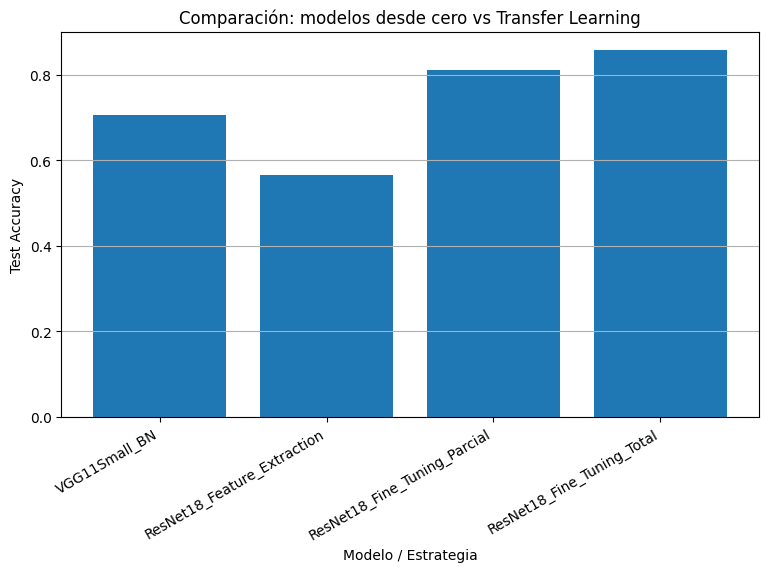

In [41]:
plt.figure(figsize=(9, 5))

plt.bar(
    df_comparacion_tarea3["Modelo"],
    df_comparacion_tarea3["Test_accuracy"]
)

plt.xlabel("Modelo / Estrategia")
plt.ylabel("Test Accuracy")
plt.title("Comparación: modelos desde cero vs Transfer Learning")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")

plt.savefig("results/figures/tarea3_comparacion_test_accuracy.png", bbox_inches="tight")
plt.show()

# Cierre del notebook

La comparación final permite identificar la mejor estrategia de Transfer Learning y justificar cuál sería recomendable en un contexto de datos médicos limitados.
